# Problem Statement 1
# Rectangular Plate: Steady-State Heat Conduction
A thin rectangular plate of width $a$ and height $b$ has three sides held at $0^\circ\mathrm{C}$ while the fourth (top) side is held at a uniform temperature $T_0$. There is no internal heat generation and the plate is thin enough that conduction may be treated as two-dimensional, so that the steady-state temperature field satisfies Laplace's equation
$$
\frac{\partial^2 T}{\partial x^2}
+
\frac{\partial^2 T}{\partial y^2}
=0,
\qquad
0 \le x \le a,
\qquad
0 \le y \le b.
$$

#### Boundary Conditions
$$
T(x,0)=0,
\qquad
T(0,y)=0,
\qquad
T(a,y)=0,
\qquad
T(x,b)=T_0.
$$

#### Data
$$
a=0.4\ \mathrm{m},
\qquad
b=0.2\ \mathrm{m},
\qquad
T_0=100^\circ\mathrm{C}.
$$

#### Analytical Solution
By separation of variables,
$$
T(x,y)
=
\frac{4T_0}{\pi}
\sum_{n=1,3,5,\ldots}^{\infty}
\frac{1}{n}
\sin\left(\frac{n\pi x}{a}\right)
\frac{
\sinh\left(\frac{n\pi y}{a}\right)
}{
\sinh\left(\frac{n\pi b}{a}\right)
}.
$$
Use enough terms to ensure the series has converged to at least **five significant figures** before using it as your benchmark.

---

**Fig. 1:** Rectangular plate with three sides at $0^\circ\mathrm{C}$ and the top side at $T_0$; inset shows the interior 5-point stencil at node $(i,j)$.

---

## Tasks
> #### Derive the standard **5-point finite-difference equation** at an interior node, and assemble the global linear system
$$
[A]\{T\}=\{b\}
$$
for a uniform grid with
$$
\Delta x = \Delta y = h.
$$
---
> #### Solve the system using a **direct method** (Gaussian elimination or LU decomposition). Record the **CPU time** and **memory used** as the grid is refined:
$$
h = 0.02,\; 0.01,\; 0.005\ \mathrm{m}.
$$
---
> #### Solve the same system using:
- Jacobi
- Gauss-Seidel
- SOR
For SOR, try at least three values of the relaxation factor $\omega$, including the theoretical optimum for a rectangular Dirichlet problem.
Record the **number of iterations** and **CPU time** for each method.
---
> #### Compare all solutions with the analytical series at the points
$$
\left(\frac{a}{4},\frac{b}{2}\right),
\qquad
\left(\frac{a}{2},\frac{b}{2}\right),
\qquad
\left(\frac{3a}{4},\frac{b}{2}\right),
\qquad
\left(\frac{a}{2},\frac{3b}{4}\right).
$$

Tabulate the **maximum absolute error** versus $h$ and confirm the expected accuracy of the 5-point scheme.
$$
O(h^2)
$$

---
> #### Summarize, in a short paragraph, how solution time scales with the number of unknowns N for the direct method versus each iterative method, and recommend a solver for this problem class
---
---
## *Numerical Methods Project Requirements*
#### 1. Discretization Derivation
Derive the finite-difference (or control-volume) discretization from first principles **before** writing any code.

#### 2. Analytical Validation
Wherever an analytical solution is given, validate your numerical solution against it at several interior points and report the **maximum absolute and percentage errors**, not just a visual comparison of plots.

#### 3. Linear System Solution
Solve the linear system $[A]\{T\} = \{b\}$ by:

- **(i) Direct method**: Gaussian elimination / LU decomposition, exploiting bandedness where possible.
- **(ii) Iterative methods**: Jacobi, Gauss–Seidel, and SOR, as specified in each problem.

For each method, report:
- Number of iterations
- Wall-clock time
- Memory footprint (as the grid is refined)

Then discuss which approach you would recommend and why.

> **Note**: Problem 3 instead uses a Picard/Newton iteration around a tridiagonal solve, and Problem 4 may be solved by any method consistent with its own tasks.

#### 4. Grid-Refinement (Convergence) Study
Perform a grid-refinement study for **every** problem. Use at least three grid sizes, with error plotted or tabulated against $\Delta x$, $\Delta r$, or $\Delta \theta$ as appropriate.

#### 5. Convergence Criteria and Parameters
State all of the following clearly:
- Convergence criteria (e.g., $\max |T^{p+1} - T^p| < 10^{-6}$)
- Initial guesses used
- Relaxation factors used (for SOR or other iterative methods)



## Import Libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy as sci

## Generate Problem Statement Schematic (Figure 1)

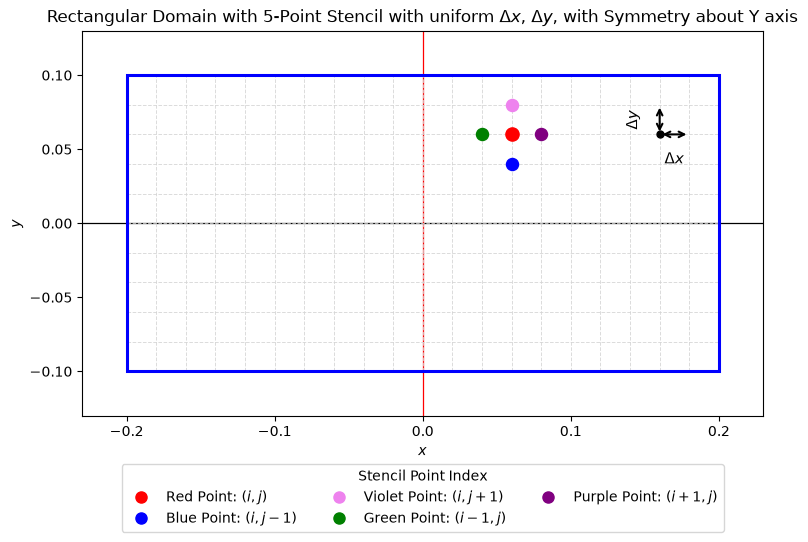

In [35]:
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

# ------------------------------------------------------------
# Geometry
# ------------------------------------------------------------
length = 0.4
breadth = 0.2
#Placeholder for Graphical representation of the domain and the stencil points
dx = 0.02
dy = 0.02
#Problem has 1 Axis of Symmetry, so we can use half the domain for the simulation. The other half can be obtained by mirroring the results.
xmin, xmax = -length / 2, length / 2
ymin, ymax = -breadth / 2, breadth / 2

# ------------------------------------------------------------
# Mesh coordinates
# ------------------------------------------------------------
x_grid = np.arange(xmin, xmax + 1e-12, dx)
y_grid = np.arange(ymin, ymax + 1e-12, dy)

# ------------------------------------------------------------
# Stencil points measured from the origin
# ------------------------------------------------------------
points = {
    "(i,j)": (3 * dx, 3 * dy),   # red
    "(i,j-1)": (3 * dx, 2 * dy),   # blue
    "(i,j+1)": (3 * dx, 4 * dy),   # violet
    "(i-1,j)": (2 * dx, 3 * dy),   # green
    "(i+1,j)": (4 * dx, 3 * dy),   # purple
}

# ------------------------------------------------------------
# Location to move delta x and delta y arrows: grid point (8,3)
# ------------------------------------------------------------
base_x = 8 * dx
base_y = 3 * dy

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))

# Faint light-grey dashed mesh
for x in x_grid:
    ax.plot( [x, x], [ymin, ymax], linestyle="--", linewidth=0.7, color="lightgrey", alpha=0.8, zorder=1)

for y in y_grid:
    ax.plot([xmin, xmax], [y, y], linestyle="--", linewidth=0.7, color="lightgrey", alpha=0.8, zorder=1)

# Rectangle boundary in LaTeX blue
ax.add_patch( Rectangle( (xmin, ymin), length, breadth, fill=False, edgecolor="#0000FF", linewidth=2.2, zorder=2 ))

# Cartesian axes through origin
ax.axhline(0, color="black", linewidth=0.9, zorder=0)
ax.axvline(0, color="Red", linewidth=0.9, zorder=0)

# ------------------------------------------------------------
# Stencil points
# ------------------------------------------------------------
ax.scatter(*points["(i,j)"], s=90, color="red", zorder=5)
ax.scatter(*points["(i,j-1)"], s=75, color="#0000FF", zorder=5)
ax.scatter(*points["(i,j+1)"], s=75, color="violet", zorder=5)
ax.scatter(*points["(i-1,j)"], s=75, color="green", zorder=5)
ax.scatter(*points["(i+1,j)"], s=75, color="purple", zorder=5)

# Mark the reference location (8,3)
ax.scatter(base_x, base_y, s=25, color="black", zorder=6)

# ------------------------------------------------------------
# Move delta x and delta y arrows to grid point (8,3)
# ------------------------------------------------------------
ax.annotate( "", xy=(base_x + dx, base_y), xytext=(base_x, base_y), arrowprops=dict( arrowstyle="<->", color="black", linewidth=1.5), zorder=6)
ax.annotate( "", xy=(base_x, base_y + dy), xytext=(base_x, base_y), arrowprops=dict( arrowstyle="<->", color="black", linewidth=1.5), zorder=6)
ax.text(base_x + dx / 2, base_y - 0.012, r"$\Delta x$", ha="center", va="top", fontsize=11)
ax.text(base_x - 0.012, base_y + dy / 2, r"$\Delta y$", ha="right", va="center", rotation=90, fontsize=11)

# ------------------------------------------------------------
# Index / legend for stencil-point colors
# ------------------------------------------------------------
legend_handles = [
    Line2D([0], [0], marker='o', linestyle='None', markerfacecolor='red', markeredgecolor='red', markersize=8, label=r"Red Point: $(i,j)$"),
    Line2D([0], [0], marker='o', linestyle='None', markerfacecolor='#0000FF', markeredgecolor='#0000FF', markersize=8, label=r"Blue Point: $(i,j-1)$"),
    Line2D([0], [0], marker='o', linestyle='None', markerfacecolor='violet', markeredgecolor='violet', markersize=8, label=r"Violet Point: $(i,j+1)$"),
    Line2D([0], [0], marker='o', linestyle='None', markerfacecolor='green', markeredgecolor='green', markersize=8, label=r"Green Point: $(i-1,j)$"),
    Line2D([0], [0], marker='o', linestyle='None', markerfacecolor='purple', markeredgecolor='purple', markersize=8, label=r"Purple Point: $(i+1,j)$"),
]

ax.legend( handles=legend_handles, loc="lower center", bbox_to_anchor=(0.5, -0.32), ncol=3, frameon=True, fontsize=10, title="Stencil Point Index")

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(xmin - 0.03, xmax + 0.03)
ax.set_ylim(ymin - 0.03, ymax + 0.03)

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.set_title(
    r"Rectangular Domain with 5-Point Stencil with uniform $\Delta x$, $\Delta y$, with Symmetry about Y axis"
)

plt.show()